In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# parameters
a = 0.9
lambd_f = 1000.0
lambd_s = 10.0
N = int(1e5)

In [22]:
# theoretical values
the_mean = a/lambd_f + (1-a)/lambd_s # from silly little exponentials
threshold = 0.05 # 50 ms
the_prob = a * np.exp(-lambd_f * threshold) + (1-a) * np.exp(-lambd_s * threshold)

In [23]:
# algorithm
U1 = np.random.uniform(0,1, size = N)
# vectorize for SPEED
B = U1 < a
U2 = np.random.uniform(0,1, size = N)

dwell_times = np.empty(N)
dwell_times[B] = -np.log(U2[B])/lambd_f
dwell_times[~B] = -np.log(U2[~B])/lambd_s

emp_mean = np.mean(dwell_times)
emp_prob = np.mean(dwell_times > threshold)




In [24]:
print(f"Theoretical Mean: {the_mean}")
print(f"Empirical Mean: {emp_mean}")
print(f"Theoretical Probability: {the_prob}")
print(f"Empirical Probability: {emp_prob}")

Theoretical Mean: 0.010899999999999998
Empirical Mean: 0.010854266240805446
Theoretical Probability: 0.060653065971263326
Empirical Probability: 0.06127


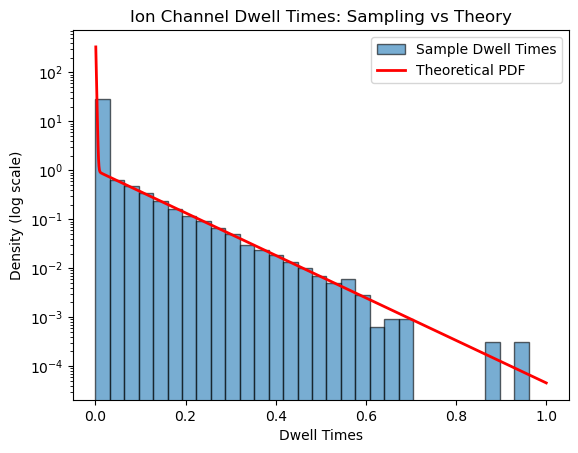

In [34]:
# plotting
x = np.linspace(0.001,1, 1000)
f_true = a * lambd_f * np.exp(-lambd_f * x) + (1-a) * lambd_s * np.exp(-lambd_s * x)
plt.hist(dwell_times, bins=30, density=True, alpha=0.6, edgecolor='black', label='Sample Dwell Times')
plt.plot(x, f_true, 'r-', lw=2, label='Theoretical PDF')
plt.yscale('log')
plt.xlabel('Dwell Times')
plt.ylabel('Density (log scale)')
plt.title('Ion Channel Dwell Times: Sampling vs Theory')
plt.legend()